In [ ]:
print(df['Timestamp'].nunique())

392690


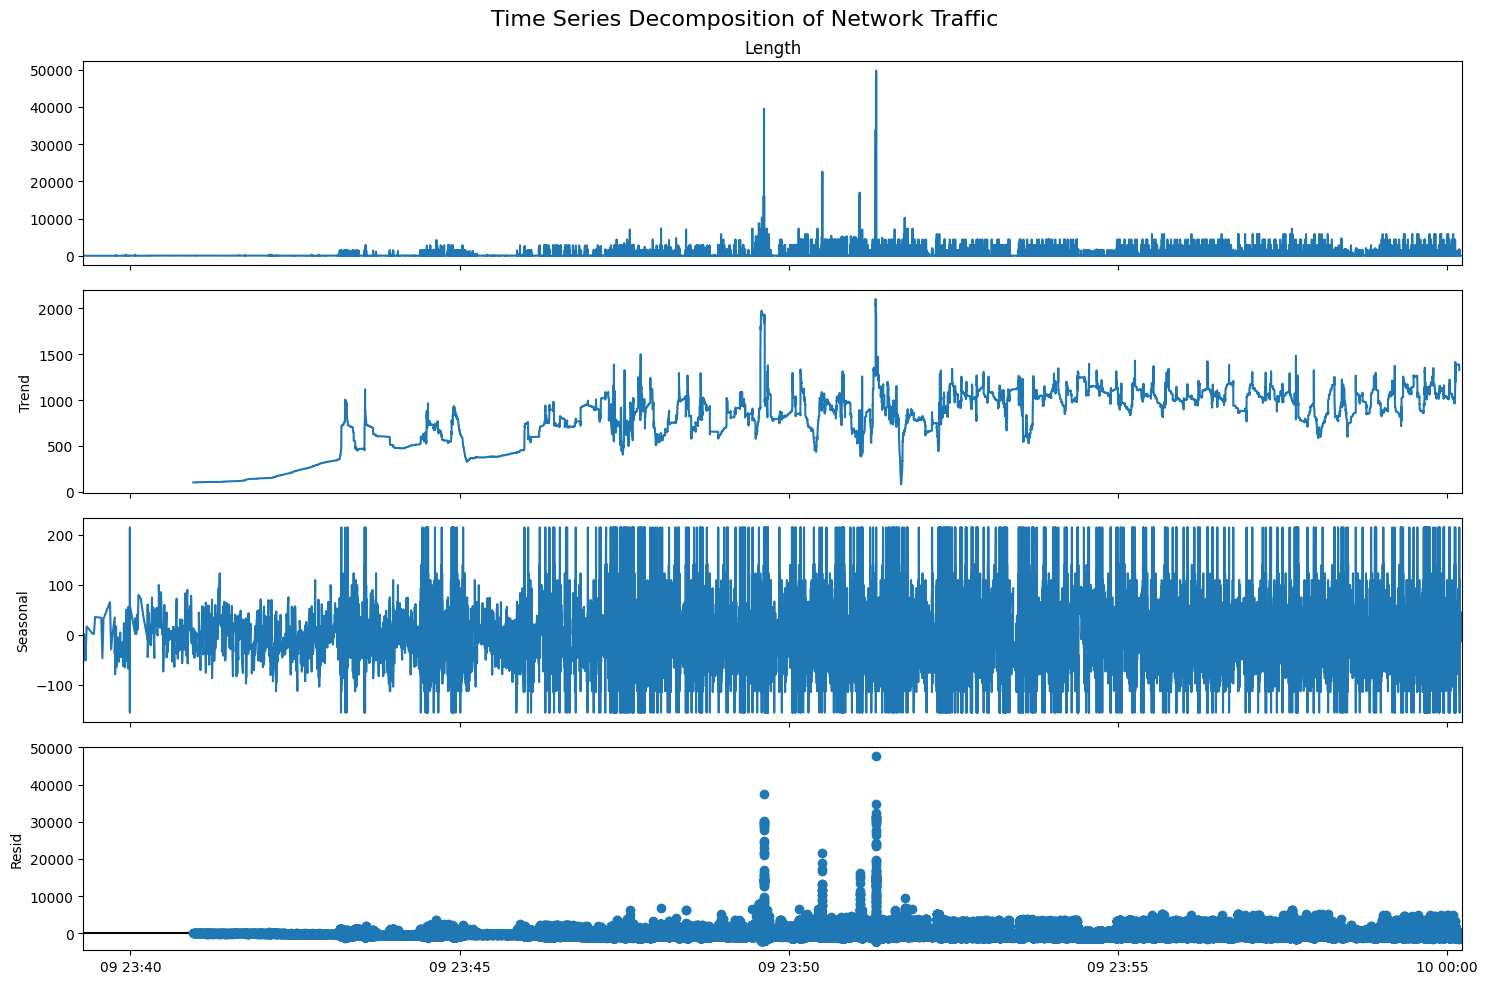

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset
df = pd.read_csv("output1.csv")

# Convert Unix timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')

# Sort by timestamp
df = df.sort_values('Timestamp')

# Set timestamp as index
df.set_index('Timestamp', inplace=True)

# Use Length as Total Traffic
traffic = df['Length']

# Fill missing values if any
traffic = traffic.interpolate()

# Perform Time Series Decomposition
decomposition = seasonal_decompose(
    traffic,
    model='additive',
    period=1000      # You can also try 500 or 1440
)

# Plot
fig = decomposition.plot()
fig.set_size_inches(15, 10)

plt.suptitle("Time Series Decomposition of Network Traffic", fontsize=16)
plt.tight_layout()
plt.show()